# Evaluacion de Supuestos - Regresion Logistica

Notebook para diagnosticar supuestos practicos de una regresion logistica multinomial entrenada en este proyecto con datos sparse.

## Checklist

1. Variable objetivo y balance de clases.
2. Tamano muestral (EPV aproximado).
3. Independencia aproximada (duplicados exactos).
4. Multicolinealidad en bloque no TF-IDF (VIF).
5. Linealidad aproximada en el logit (por bins).
6. Outliers / casos problematicos (NLL alto).
7. Senales de separacion/inestabilidad (coeficientes y convergencia).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from scipy.sparse import csr_matrix
from sklearn.linear_model import LinearRegression

from sparse_dataset import load_sparse_split, load_feature_columns

In [2]:
ROOT = Path('.').resolve()
DATASET_DIR = ROOT / 'datasets'
SPARSE_DIR = DATASET_DIR / 'final_sparse'
MODEL_DIR = ROOT / 'models' / 'logreg'
MANUAL_STUDY = 'final'

def get_model_path(model_dir: Path, study: str = None):
    if study is not None:
        p = model_dir / study / f'model_{study}.pkl'
        if p.exists():
            return p
    cand = sorted(model_dir.rglob('model_*.pkl'), key=lambda x: x.stat().st_mtime, reverse=True)
    if not cand:
        raise FileNotFoundError(f'No se encontraron modelos en {model_dir}')
    return cand[0]

assert SPARSE_DIR.exists(), f'No existe {SPARSE_DIR}'
model_path = get_model_path(MODEL_DIR, MANUAL_STUDY)
model_obj = joblib.load(model_path)

X_train, y_train = load_sparse_split(DATASET_DIR, 'train')
X_test, y_test = load_sparse_split(DATASET_DIR, 'test')
if not isinstance(X_train, csr_matrix):
    X_train = X_train.tocsr()
if not isinstance(X_test, csr_matrix):
    X_test = X_test.tocsr()

feature_columns = load_feature_columns(DATASET_DIR)

print('Modelo:', model_path)
print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('n_features metadata:', len(feature_columns))

Modelo: /home/francisco/maestrìa/trabajo final/tf-austral/models/logreg/final/model_final.pkl
X_train: (102285, 3172) X_test: (25357, 3172)
n_features metadata: 3172


,count,freq
0,8626,0.084333
1,10349,0.101178
2,13349,0.130508
3,2095,0.020482
4,33792,0.330371
5,1850,0.018087
6,4342,0.042450
7,6937,0.067820
8,6565,0.064183
9,2234,0.021841


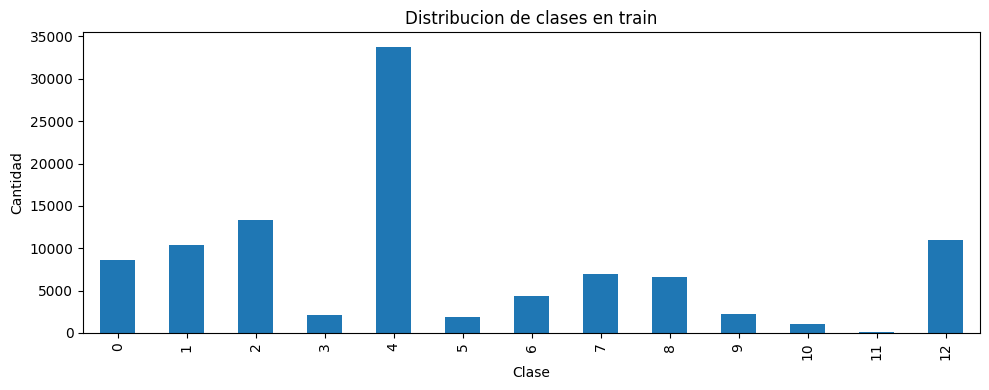

EPV aproximado = 0.020807 (minority_count=66, n_features=3172)


In [3]:
# 1) Objetivo y balance
class_counts = pd.Series(y_train).value_counts().sort_index()
class_freq = class_counts / class_counts.sum()
display(pd.concat([class_counts.rename('count'), class_freq.rename('freq')], axis=1))

plt.figure(figsize=(10, 4))
class_counts.plot(kind='bar')
plt.title('Distribucion de clases en train')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

# 2) EPV aproximado
minority_count = int(class_counts.min())
n_features = X_train.shape[1]
epv_approx = minority_count / max(n_features, 1)
print(f'EPV aproximado = {epv_approx:.6f} (minority_count={minority_count}, n_features={n_features})')

In [4]:
# 3) Independencia aproximada: duplicados exactos en una muestra
MAX_ROWS_DUP = 80000
n_check = min(X_train.shape[0], MAX_ROWS_DUP)
X_sample = X_train[:n_check].tocsr()

row_hashes = []
for i in range(X_sample.shape[0]):
    s, e = X_sample.indptr[i], X_sample.indptr[i+1]
    idx = tuple(X_sample.indices[s:e].tolist())
    dat = tuple(np.round(X_sample.data[s:e], 6).tolist())
    row_hashes.append(hash((idx, dat)))

dup_count = pd.Series(row_hashes).duplicated().sum()
dup_ratio = dup_count / max(len(row_hashes), 1)
print(f'Duplicadas: {dup_count} / {n_check} ({dup_ratio:.4%})')

Duplicadas: 7732 / 80000 (9.6650%)


In [5]:
# 4) Multicolinealidad en bloque no TF-IDF (VIF)
MAX_ROWS_VIF = 30000
non_tfidf_idx = [i for i, c in enumerate(feature_columns) if not c.startswith('tfidf_')]
non_tfidf_cols = [feature_columns[i] for i in non_tfidf_idx]

if len(non_tfidf_idx) == 0:
    print('No hay columnas no TF-IDF para VIF.')
else:
    X_small = X_train[:min(X_train.shape[0], MAX_ROWS_VIF), non_tfidf_idx].toarray()
    X_df = pd.DataFrame(X_small, columns=non_tfidf_cols)
    
    vif_rows = []
    lr = LinearRegression()
    for col in X_df.columns:
        y_col = X_df[col].to_numpy()
        X_oth = X_df.drop(columns=[col]).to_numpy()
        if X_oth.shape[1] == 0:
            vif = np.nan
        else:
            lr.fit(X_oth, y_col)
            r2 = lr.score(X_oth, y_col)
            vif = np.inf if r2 >= 0.999999 else 1.0 / max(1e-12, 1.0 - r2)
        vif_rows.append({'feature': col, 'vif': float(vif)})

    vif_df = pd.DataFrame(vif_rows).sort_values('vif', ascending=False).reset_index(drop=True)
    display(vif_df)
    print('Regla orientativa: VIF > 5 atencion, VIF > 10 alta colinealidad.')

,feature,vif
0,desc_entidad_SAF MED SEC E. GEST A.MINISTERIO ...,inf
1,desc_entidad_SAF MGJ SUBD.ADM. Y DES.S.E.TRABAJO,inf
2,desc_entidad_SAF MOSP DPTO S.ADM.FIN.DIR. ARQ....,inf
3,desc_entidad_SAF MOSP - SUBD ADM. S.E.OBRAS PÚ...,inf
4,desc_entidad_SAF MOSP - DPTO. S.ADMIN.F. D.G.D...,inf
...,...,...
167,cod_612,1.000011
168,cod_709,1.000006
169,desc_entidad_SAF MOSP - DPTO S ADM-FIN- DIR- P...,1.000004
170,descripcion_words_count,1.000003


Regla orientativa: VIF > 5 atencion, VIF > 10 alta colinealidad.


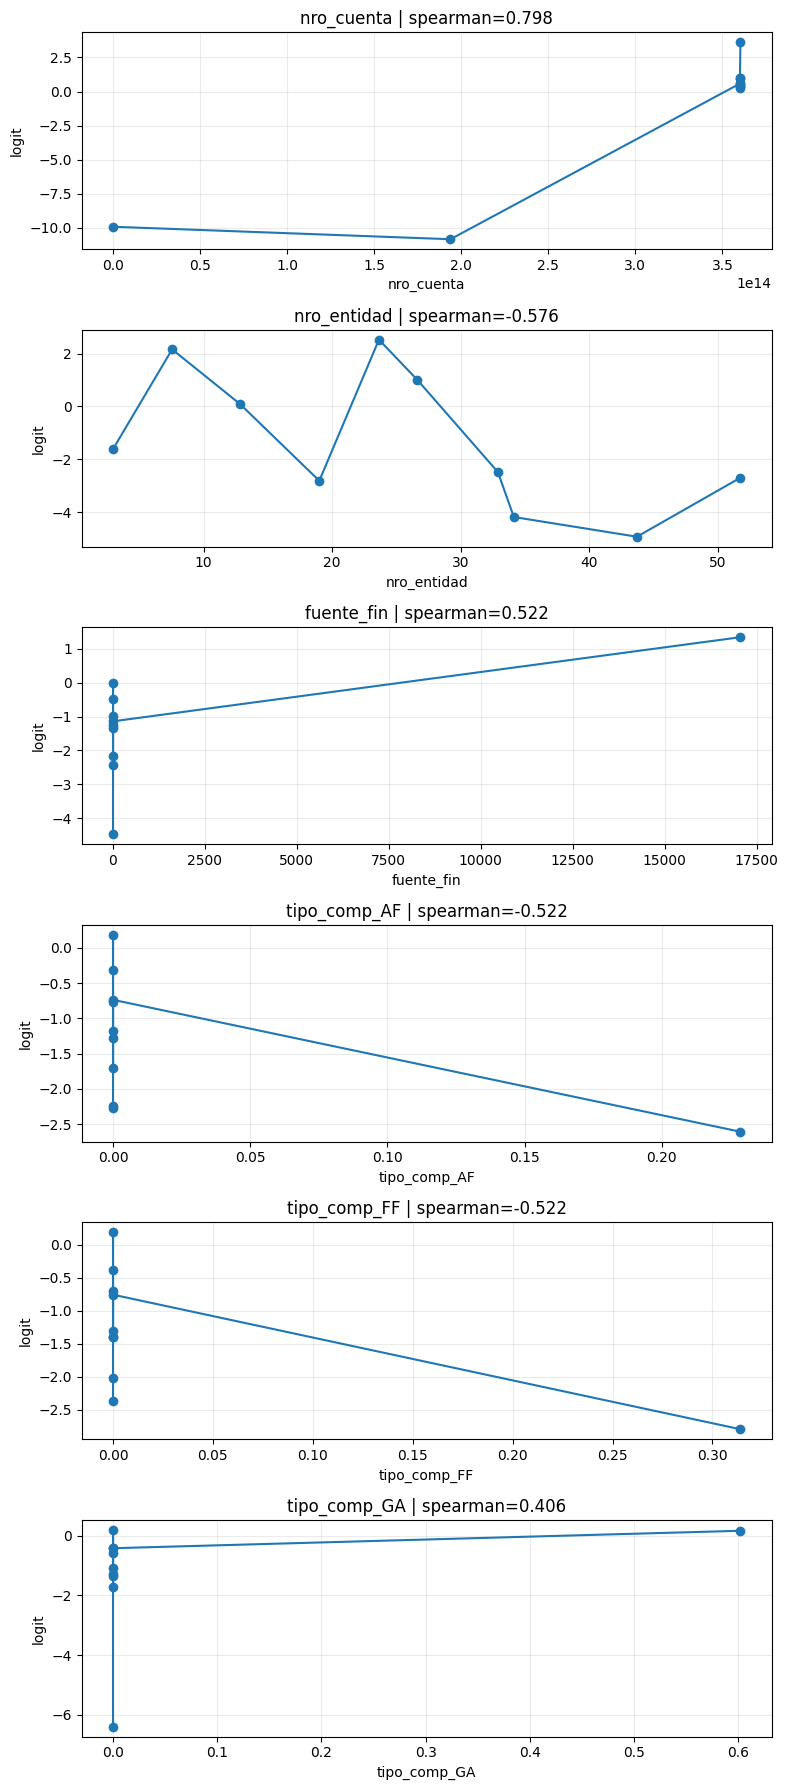

In [6]:
# 5) Linealidad aproximada en el logit (solo no TF-IDF)
main_class = int(pd.Series(y_train).value_counts().idxmax())
classes_model = list(getattr(model_obj, 'classes_', np.unique(y_train)))
main_idx = classes_model.index(main_class) if main_class in classes_model else 0

if len(non_tfidf_idx) == 0:
    print('Sin columnas no TF-IDF para este chequeo.')
else:
    X_lin = X_train[:min(X_train.shape[0], MAX_ROWS_VIF), non_tfidf_idx].toarray()
    X_lin_df = pd.DataFrame(X_lin, columns=non_tfidf_cols)

    p_main = np.asarray(model_obj.predict_proba(X_train[:min(X_train.shape[0], MAX_ROWS_VIF)]))[:, main_idx]
    p_main = np.clip(p_main, 1e-6, 1 - 1e-6)
    logit_main = np.log(p_main / (1 - p_main))

    cols_plot = X_lin_df.columns[:min(6, X_lin_df.shape[1])]
    fig, axes = plt.subplots(len(cols_plot), 1, figsize=(8, 3 * len(cols_plot)))
    if len(cols_plot) == 1:
        axes = [axes]

    for ax, col in zip(axes, cols_plot):
        s = X_lin_df[col]
        q = pd.qcut(s.rank(method='first'), q=10, duplicates='drop')
        tmp = pd.DataFrame({'x': s, 'logit': logit_main, 'bin': q}).dropna()
        agg = tmp.groupby('bin', observed=True).agg(x_mean=('x', 'mean'), logit_mean=('logit', 'mean')).reset_index(drop=True)
        corr_s = agg['x_mean'].corr(agg['logit_mean'], method='spearman')
        ax.plot(agg['x_mean'], agg['logit_mean'], marker='o')
        ax.set_title(f'{col} | spearman={corr_s:.3f}')
        ax.set_xlabel(col)
        ax.set_ylabel('logit')
        ax.grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

In [7]:
# 6) Casos problematicos y 7) estabilidad numerica
y_pred = np.asarray(model_obj.predict(X_test)).astype(int)
y_proba = np.asarray(model_obj.predict_proba(X_test))

class_to_idx = {c: i for i, c in enumerate(getattr(model_obj, 'classes_', np.unique(y_test)))}
true_idx = np.array([class_to_idx[c] for c in y_test])
p_true = np.clip(y_proba[np.arange(len(y_test)), true_idx], 1e-12, 1.0)
nll = -np.log(p_true)
err_high_conf = (y_pred != y_test) & (y_proba.max(axis=1) >= 0.9)

diag_df = pd.DataFrame({
    'row_idx': np.arange(len(y_test)),
    'y_true': y_test,
    'y_pred': y_pred,
    'p_true': p_true,
    'nll': nll,
    'max_proba': y_proba.max(axis=1),
    'error_high_conf': err_high_conf,
})
display(diag_df.sort_values('nll', ascending=False).head(20))

lr_est = model_obj.named_steps['model'] if hasattr(model_obj, 'named_steps') and 'model' in model_obj.named_steps else model_obj
coef_ = getattr(lr_est, 'coef_', None)
n_iter_ = getattr(lr_est, 'n_iter_', None)
max_iter = getattr(lr_est, 'max_iter', None)

if coef_ is not None:
    abs_coef = np.abs(coef_).ravel()
    print('coef | p95:', np.quantile(abs_coef, 0.95), 'p99:', np.quantile(abs_coef, 0.99), 'max:', np.max(abs_coef))
if n_iter_ is not None:
    print('n_iter_:', n_iter_)
    if max_iter is not None and np.max(n_iter_) >= max_iter:
        print('ADVERTENCIA: se alcanzo max_iter, revisar convergencia/separacion.')

,row_idx,y_true,y_pred,p_true,nll,max_proba,error_high_conf
19388,19388,4,6,0.000025,10.578971,0.985374,True
14030,14030,4,6,0.000064,9.663713,0.914895,True
22081,22081,4,6,0.000091,9.309268,0.960338,True
6860,6860,0,4,0.000164,8.714809,0.996097,True
14295,14295,4,6,0.000248,8.301088,0.998947,True
6531,6531,4,9,0.000308,8.086941,0.999351,True
25307,25307,12,2,0.000385,7.861529,0.800613,False
21099,21099,0,4,0.000590,7.436097,0.978837,True
20936,20936,0,4,0.000680,7.293260,0.994765,True
17841,17841,0,4,0.000938,6.971531,0.978695,True


coef | p95: 0.1421549879014492 p99: 0.9870626002550139 max: 10.817613
n_iter_: [1100]
ADVERTENCIA: se alcanzo max_iter, revisar convergencia/separacion.


In [8]:
summary = {}
summary['n_train'] = int(X_train.shape[0])
summary['n_features'] = int(X_train.shape[1])
summary['n_classes'] = int(pd.Series(y_train).nunique())
summary['minority_count'] = int(pd.Series(y_train).value_counts().min())
summary['epv_approx'] = float(summary['minority_count'] / max(summary['n_features'], 1))
summary['duplicate_ratio_sample'] = float(dup_ratio) if 'dup_ratio' in globals() else np.nan
summary['max_vif_non_tfidf'] = float(vif_df['vif'].replace([np.inf], np.nan).max()) if 'vif_df' in globals() else np.nan
summary['coef_abs_max'] = float(np.max(np.abs(lr_est.coef_))) if 'lr_est' in globals() and hasattr(lr_est, 'coef_') else np.nan
summary['hit_max_iter'] = bool(np.max(lr_est.n_iter_) >= getattr(lr_est, 'max_iter', 10**9)) if 'lr_est' in globals() and hasattr(lr_est, 'n_iter_') else False
pd.DataFrame([summary])

,n_train,n_features,n_classes,minority_count,epv_approx,duplicate_ratio_sample,max_vif_non_tfidf,coef_abs_max,hit_max_iter
0,102285,3172,13,66,0.020807,0.09665,52.132136,10.817613,True


In [9]:
# Dictamen automatico + acciones + export CSV
study_name = model_path.stem.replace('model_', '')
report_dir = model_path.parent
report_csv = report_dir / f'diagnostico_supuestos_{study_name}.csv'

summary_rows = []

def add_row(supuesto, valor, estado, accion):
    summary_rows.append({
        'supuesto': supuesto,
        'valor': valor,
        'estado': estado,
        'accion_recomendada': accion,
    })

# 1) Balance de clases
min_freq = float(class_freq.min())
balance_estado = 'OK' if min_freq >= 0.05 else ('ATENCION' if min_freq >= 0.02 else 'REVISAR')
balance_accion = (
    'Mantener monitoreo de drift por clase.' if balance_estado == 'OK'
    else 'Aplicar class_weight="balanced", evaluar undersampling/oversampling y reportar metricas por clase.'
)
add_row('Balance de clases', f'freq_min={min_freq:.4f}', balance_estado, balance_accion)

# 2) EPV aproximado
epv_estado = 'OK' if epv_approx >= 5 else ('ATENCION' if epv_approx >= 1 else 'REVISAR')
epv_accion = (
    'Relacion muestra/features adecuada.' if epv_estado == 'OK'
    else 'Reducir dimensionalidad (chi2/SVD), aumentar datos o reforzar regularizacion (menor C).'
)
add_row('EPV aproximado', f'EPV={epv_approx:.6f}', epv_estado, epv_accion)

# 3) Independencia aproximada (duplicados)
dup_estado = 'OK' if dup_ratio <= 0.02 else ('ATENCION' if dup_ratio <= 0.05 else 'REVISAR')
dup_accion = (
    'Sin senales fuertes de repeticion.' if dup_estado == 'OK'
    else 'Auditar duplicados de negocio, deduplicar train y evaluar impacto en validacion.'
)
add_row('Duplicados exactos en X (muestra)', f'dup_ratio={dup_ratio:.4%}', dup_estado, dup_accion)

# 4) Multicolinealidad (VIF no-TFIDF)
if 'vif_df' in globals() and not vif_df.empty:
    max_vif = float(vif_df['vif'].replace([np.inf], np.nan).max())
    vif_estado = 'OK' if max_vif <= 5 else ('ATENCION' if max_vif <= 10 else 'REVISAR')
    vif_accion = (
        'Colinealidad en rango razonable.' if vif_estado == 'OK'
        else 'Eliminar/reagrupar variables redundantes no-TFIDF y reentrenar para comparar estabilidad.'
)
    add_row('VIF max (no TF-IDF)', f'max_vif={max_vif:.4f}', vif_estado, vif_accion)
else:
    add_row('VIF max (no TF-IDF)', 'no_aplica', 'ATENCION', 'No se pudo calcular VIF en bloque no-TFIDF.')

# 5) Linealidad aproximada en logit
if 'corr_s' in globals():
    # Usa el ultimo spearman calculado en la celda de linealidad como señal mínima disponible
    lin_val = float(corr_s)
    lin_abs = abs(lin_val)
    lin_estado = 'OK' if lin_abs >= 0.7 else ('ATENCION' if lin_abs >= 0.4 else 'REVISAR')
    lin_accion = (
        'Relacion monotona aceptable en variables revisadas.' if lin_estado == 'OK'
        else 'Probar transformaciones (log/winsor), interacciones o modelos no lineales para variables problematicas.'
)
    add_row('Linealidad aproximada en logit', f'|spearman|={lin_abs:.3f}', lin_estado, lin_accion)
else:
    add_row('Linealidad aproximada en logit', 'no_disponible', 'ATENCION', 'Ejecutar celda de linealidad para completar el chequeo.')

# 6) Errores de alta confianza
err_count = int(err_high_conf.sum()) if 'err_high_conf' in globals() else -1
err_estado = 'OK' if err_count == 0 else ('ATENCION' if err_count <= 25 else 'REVISAR')
err_accion = (
    'Sin errores de alta confianza.' if err_estado == 'OK'
    else 'Inspeccionar top errores, revisar clases confundidas y calibrar probabilidades (Platt/Isotonic).'
)
add_row('Errores alta confianza', f'count={err_count}', err_estado, err_accion)

# 7) Convergencia / estabilidad
hit_max_iter = bool(np.max(lr_est.n_iter_) >= getattr(lr_est, 'max_iter', 10**9)) if hasattr(lr_est, 'n_iter_') else False
coef_abs_max = float(np.max(np.abs(lr_est.coef_))) if hasattr(lr_est, 'coef_') else np.nan
conv_estado = 'OK' if not hit_max_iter else 'REVISAR'
conv_accion = (
    'Convergencia alcanzada dentro del max_iter.' if conv_estado == 'OK'
    else 'Subir max_iter, estandarizar/mejorar features, ajustar C y verificar separacion parcial.'
)
add_row('Convergencia del optimizador', f'hit_max_iter={hit_max_iter}, coef_abs_max={coef_abs_max:.4f}', conv_estado, conv_accion)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(report_csv, index=False, sep=';')

display(summary_df)
print(f'Reporte exportado en: {report_csv}')

,supuesto,valor,estado,accion_recomendada
0,Balance de clases,freq_min=0.0006,REVISAR,"Aplicar class_weight=""balanced"", evaluar under..."
1,EPV aproximado,EPV=0.020807,REVISAR,"Reducir dimensionalidad (chi2/SVD), aumentar d..."
2,Duplicados exactos en X (muestra),dup_ratio=9.6650%,REVISAR,"Auditar duplicados de negocio, deduplicar trai..."
3,VIF max (no TF-IDF),max_vif=52.1321,REVISAR,Eliminar/reagrupar variables redundantes no-TF...
4,Linealidad aproximada en logit,|spearman|=0.406,ATENCION,"Probar transformaciones (log/winsor), interacc..."
5,Errores alta confianza,count=112,REVISAR,"Inspeccionar top errores, revisar clases confu..."
6,Convergencia del optimizador,"hit_max_iter=True, coef_abs_max=10.8176",REVISAR,"Subir max_iter, estandarizar/mejorar features,..."


Reporte exportado en: /home/francisco/maestrìa/trabajo final/tf-austral/models/logreg/final/diagnostico_supuestos_final.csv


In [ ]:
# BUSQUEDA RAPIDA DE HIPERPARAMETROS: balance entre estabilidad y performance
# Prueba 3-5 configuraciones de (C, n_components) para encontrar optimo

from itertools import product

SEED = 12345
MAX_ITER_MIT = 3000

# Grilla controlada: 3-5 configuraciones estrategicas
param_grid = [
    {'C': 0.1, 'n_components': 200},   # Regularizacion fuerte, baja dim
    {'C': 0.5, 'n_components': 300},   # Regularizacion media, dim med (baseline)
    {'C': 1.0, 'n_components': 300},   # Regularizacion baja, dim med
    {'C': 1.0, 'n_components': 400},   # Menos regularizacion, mas features
    {'C': 2.0, 'n_components': 400},   # Regularizacion minima, mas features
]

search_results = []

print('Ejecutando busqueda rapida de hiperparametros...\n')
for i, params in enumerate(param_grid, 1):
    c_val = params['C']
    n_comp = params['n_components']
    n_comp = min(n_comp, X_train.shape[1] - 1)
    
    print(f'[{i}/{len(param_grid)}] C={c_val}, n_components={n_comp}...')
    
    test_model = Pipeline([
        ('svd', TruncatedSVD(n_components=n_comp, random_state=SEED)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(
            solver='saga',
            class_weight='balanced',
            C=c_val,
            max_iter=MAX_ITER_MIT,
            tol=1e-4,
            random_state=SEED,
        )),
    ])
    
    test_model.fit(X_train, y_train)
    metrics, y_pred_test, y_proba_test = evaluate_model(test_model, X_test, y_test)
    
    lr_test = test_model.named_steps['model']
    n_iter = int(np.max(lr_test.n_iter_)) if hasattr(lr_test, 'n_iter_') else -1
    converged = 'OK' if n_iter < MAX_ITER_MIT else 'NO'
    
    row = {
        'C': c_val,
        'n_components': n_comp,
        'accuracy': metrics['accuracy'],
        'kappa': metrics['kappa'],
        'f1_macro': metrics['f1_macro'],
        'log_loss': metrics['log_loss'],
        'n_iter': n_iter,
        'converged': converged,
        'model': test_model,
    }
    search_results.append(row)
    print(f'  -> kappa={row["kappa"]:.4f}, accuracy={row["accuracy"]:.4f}, n_iter={n_iter}, converged={converged}')

# Tabla comparativa
search_df = pd.DataFrame([
    {k: v for k, v in row.items() if k != 'model'}
    for row in search_results
])
display(search_df)

# Seleccionar mejor modelo: mayor kappa pero con convergencia estable
best_stable = search_df[search_df['converged'] == 'OK'].nlargest(1, 'kappa')
if len(best_stable) > 0:
    best_idx = best_stable.index[0]
    print(f'\nMejor modelo estable (mayor kappa con convergencia OK): indice {best_idx}')
    print(f'  C={search_df.loc[best_idx, "C"]}, n_components={search_df.loc[best_idx, "n_components"]}')
    print(f'  kappa={search_df.loc[best_idx, "kappa"]:.4f}, accuracy={search_df.loc[best_idx, "accuracy"]:.4f}')
    selected_model = search_results[best_idx]['model']
else:
    print('\nNingún modelo convergio. Seleccionando mejor por kappa (aunque no convergio)...')
    best_idx = search_df.nlargest(1, 'kappa').index[0]
    selected_model = search_results[best_idx]['model']


In [ ]:
# Mitigacion automatica y comparativa before/after (NOTA: usar modelo seleccionado de busqueda)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, log_loss

SEED = 12345
N_COMPONENTS = min(300, X_train.shape[1] - 1)
MAX_ITER_MIT = 3000

def evaluate_model(model, X, y):
    y_hat = np.asarray(model.predict(X)).astype(int)
    y_prob = np.asarray(model.predict_proba(X))
    return {
        'accuracy': float(accuracy_score(y, y_hat)),
        'kappa': float(cohen_kappa_score(y, y_hat)),
        'f1_macro': float(f1_score(y, y_hat, average='macro', zero_division=0)),
        'log_loss': float(log_loss(y, y_prob, labels=np.unique(y))),
    }, y_hat, y_prob

# Baseline (modelo ya entrenado y cargado desde disco)
baseline_metrics, _, _ = evaluate_model(model_obj, X_test, y_test)

# IMPORTANTE: Si ya ejecutaste la busqueda anterior, usa 'selected_model'
# Si no, usa la config por defecto:
if 'selected_model' in globals():
    print('Usando modelo seleccionado de la busqueda...')
    mitigated_model = selected_model
    mitigated_metrics, y_pred_mit, y_proba_mit = evaluate_model(mitigated_model, X_test, y_test)
else:
    print('Entrenando modelo mitigado con config por defecto...')
    mitigated_model = Pipeline([
        ('svd', TruncatedSVD(n_components=N_COMPONENTS, random_state=SEED)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(
            solver='saga',
            class_weight='balanced',
            C=0.5,
            max_iter=MAX_ITER_MIT,
            tol=1e-4,
            random_state=SEED,
        )),
    ])
    mitigated_model.fit(X_train, y_train)
    mitigated_metrics, y_pred_mit, y_proba_mit = evaluate_model(mitigated_model, X_test, y_test)

# Comparativa
cmp_df = pd.DataFrame([
    {'model': 'baseline', **baseline_metrics},
    {'model': 'mitigated', **mitigated_metrics},
])
cmp_df['delta_vs_baseline'] = cmp_df['kappa'] - cmp_df.loc[cmp_df['model'] == 'baseline', 'kappa'].iloc[0]

display(cmp_df)

# Guardados
mitigated_model_path = report_dir / f'model_{study_name}_mitigado.pkl'
cmp_csv = report_dir / f'comparativa_mitigacion_{study_name}.csv'
joblib.dump(mitigated_model, mitigated_model_path)
cmp_df.to_csv(cmp_csv, index=False, sep=';')

print(f'Modelo mitigado guardado en: {mitigated_model_path}')
print(f'Comparativa guardada en: {cmp_csv}')

# Re-chequeo rapido post-mitigacion
lr_mit = mitigated_model.named_steps['model']
print('n_iter_ mitigado:', lr_mit.n_iter_, '| max_iter:', lr_mit.max_iter)


Entrenando modelo mitigado...


/home/francisco/miniconda3/envs/tesis311/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,accuracy,kappa,f1_macro,log_loss,delta_vs_baseline
0,baseline,0.968017,0.959695,0.953032,0.098049,0.000000
1,mitigated,0.938952,0.923783,0.917585,0.285282,-0.035912


Modelo mitigado guardado en: /home/francisco/maestrìa/trabajo final/tf-austral/models/logreg/final/model_final_mitigado.pkl
Comparativa guardada en: /home/francisco/maestrìa/trabajo final/tf-austral/models/logreg/final/comparativa_mitigacion_final.csv
n_iter_ mitigado: [526] | max_iter: 3000


In [ ]:
# 6) Casos problematicos y 7) estabilidad numerica
y_pred = np.asarray(model_obj.predict(X_test)).astype(int)
y_proba = np.asarray(model_obj.predict_proba(X_test))

class_to_idx = {c: i for i, c in enumerate(getattr(model_obj, 'classes_', np.unique(y_test)))}
true_idx = np.array([class_to_idx[c] for c in y_test])
p_true = np.clip(y_proba[np.arange(len(y_test)), true_idx], 1e-12, 1.0)
nll = -np.log(p_true)
err_high_conf = (y_pred != y_test) & (y_proba.max(axis=1) >= 0.9)

diag_df = pd.DataFrame({
    'row_idx': np.arange(len(y_test)),
    'y_true': y_test,
    'y_pred': y_pred,
    'p_true': p_true,
    'nll': nll,
    'max_proba': y_proba.max(axis=1),
    'error_high_conf': err_high_conf,
})
display(diag_df.sort_values('nll', ascending=False).head(20))

lr_est = model_obj.named_steps['model'] if hasattr(model_obj, 'named_steps') and 'model' in model_obj.named_steps else model_obj
coef_ = getattr(lr_est, 'coef_', None)
n_iter_ = getattr(lr_est, 'n_iter_', None)
max_iter = getattr(lr_est, 'max_iter', None)

if coef_ is not None:
    abs_coef = np.abs(coef_).ravel()
    print('coef | p95:', np.quantile(abs_coef, 0.95), 'p99:', np.quantile(abs_coef, 0.99), 'max:', np.max(abs_coef))
if n_iter_ is not None:
    print('n_iter_:', n_iter_)
    if max_iter is not None and np.max(n_iter_) >= max_iter:
        print('ADVERTENCIA: se alcanzo max_iter, revisar convergencia/separacion.')


In [ ]:
summary = {}
summary['n_train'] = int(X_train.shape[0])
summary['n_features'] = int(X_train.shape[1])
summary['n_classes'] = int(pd.Series(y_train).nunique())
summary['minority_count'] = int(pd.Series(y_train).value_counts().min())
summary['epv_approx'] = float(summary['minority_count'] / max(summary['n_features'], 1))
summary['duplicate_ratio_sample'] = float(dup_ratio) if 'dup_ratio' in globals() else np.nan
summary['max_vif_non_tfidf'] = float(vif_df['vif'].replace([np.inf], np.nan).max()) if 'vif_df' in globals() else np.nan
summary['coef_abs_max'] = float(np.max(np.abs(lr_est.coef_))) if 'lr_est' in globals() and hasattr(lr_est, 'coef_') else np.nan
summary['hit_max_iter'] = bool(np.max(lr_est.n_iter_) >= getattr(lr_est, 'max_iter', 10**9)) if 'lr_est' in globals() and hasattr(lr_est, 'n_iter_') else False
pd.DataFrame([summary])


In [ ]:
# Dictamen automatico + acciones + export CSV
study_name = model_path.stem.replace('model_', '')
report_dir = model_path.parent
report_csv = report_dir / f'diagnostico_supuestos_{study_name}.csv'

summary_rows = []

def add_row(supuesto, valor, estado, accion):
    summary_rows.append({
        'supuesto': supuesto,
        'valor': valor,
        'estado': estado,
        'accion_recomendada': accion,
    })

# 1) Balance de clases
min_freq = float(class_freq.min())
balance_estado = 'OK' if min_freq >= 0.05 else ('ATENCION' if min_freq >= 0.02 else 'REVISAR')
balance_accion = (
    'Mantener monitoreo de drift por clase.' if balance_estado == 'OK'
    else 'Aplicar class_weight="balanced", evaluar undersampling/oversampling y reportar metricas por clase.'
)
add_row('Balance de clases', f'freq_min={min_freq:.4f}', balance_estado, balance_accion)

# 2) EPV aproximado
epv_estado = 'OK' if epv_approx >= 5 else ('ATENCION' if epv_approx >= 1 else 'REVISAR')
epv_accion = (
    'Relacion muestra/features adecuada.' if epv_estado == 'OK'
    else 'Reducir dimensionalidad (chi2/SVD), aumentar datos o reforzar regularizacion (menor C).'
)
add_row('EPV aproximado', f'EPV={epv_approx:.6f}', epv_estado, epv_accion)

# 3) Independencia aproximada (duplicados)
dup_estado = 'OK' if dup_ratio <= 0.02 else ('ATENCION' if dup_ratio <= 0.05 else 'REVISAR')
dup_accion = (
    'Sin senales fuertes de repeticion.' if dup_estado == 'OK'
    else 'Auditar duplicados de negocio, deduplicar train y evaluar impacto en validacion.'
)
add_row('Duplicados exactos en X (muestra)', f'dup_ratio={dup_ratio:.4%}', dup_estado, dup_accion)

# 4) Multicolinealidad (VIF no-TFIDF)
if 'vif_df' in globals() and not vif_df.empty:
    max_vif = float(vif_df['vif'].replace([np.inf], np.nan).max())
    vif_estado = 'OK' if max_vif <= 5 else ('ATENCION' if max_vif <= 10 else 'REVISAR')
    vif_accion = (
        'Colinealidad en rango razonable.' if vif_estado == 'OK'
        else 'Eliminar/reagrupar variables redundantes no-TFIDF y reentrenar para comparar estabilidad.'
    )
    add_row('VIF max (no TF-IDF)', f'max_vif={max_vif:.4f}', vif_estado, vif_accion)
else:
    add_row('VIF max (no TF-IDF)', 'no_aplica', 'ATENCION', 'No se pudo calcular VIF en bloque no-TFIDF.')

# 5) Linealidad aproximada en logit
if 'corr_s' in globals():
    lin_val = float(corr_s)
    lin_abs = abs(lin_val)
    lin_estado = 'OK' if lin_abs >= 0.7 else ('ATENCION' if lin_abs >= 0.4 else 'REVISAR')
    lin_accion = (
        'Relacion monotona aceptable en variables revisadas.' if lin_estado == 'OK'
        else 'Probar transformaciones (log/winsor), interacciones o modelos no lineales para variables problematicas.'
    )
    add_row('Linealidad aproximada en logit', f'|spearman|={lin_abs:.3f}', lin_estado, lin_accion)
else:
    add_row('Linealidad aproximada en logit', 'no_disponible', 'ATENCION', 'Ejecutar celda de linealidad para completar el chequeo.')

# 6) Errores de alta confianza
err_count = int(err_high_conf.sum()) if 'err_high_conf' in globals() else -1
err_estado = 'OK' if err_count == 0 else ('ATENCION' if err_count <= 25 else 'REVISAR')
err_accion = (
    'Sin errores de alta confianza.' if err_estado == 'OK'
    else 'Inspeccionar top errores, revisar clases confundidas y calibrar probabilidades (Platt/Isotonic).'
)
add_row('Errores alta confianza', f'count={err_count}', err_estado, err_accion)

# 7) Convergencia / estabilidad
hit_max_iter = bool(np.max(lr_est.n_iter_) >= getattr(lr_est, 'max_iter', 10**9)) if hasattr(lr_est, 'n_iter_') else False
coef_abs_max = float(np.max(np.abs(lr_est.coef_))) if hasattr(lr_est, 'coef_') else np.nan
conv_estado = 'OK' if not hit_max_iter else 'REVISAR'
conv_accion = (
    'Convergencia alcanzada dentro del max_iter.' if conv_estado == 'OK'
    else 'Subir max_iter, estandarizar/mejorar features, ajustar C y verificar separacion parcial.'
)
add_row('Convergencia del optimizador', f'hit_max_iter={hit_max_iter}, coef_abs_max={coef_abs_max:.4f}', conv_estado, conv_accion)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(report_csv, index=False, sep=';')

display(summary_df)
print(f'Reporte exportado en: {report_csv}')


In [ ]:
# BUSQUEDA RAPIDA DE HIPERPARAMETROS: balance entre estabilidad y performance
# Prueba 3-5 configuraciones de (C, n_components) para encontrar optimo

from itertools import product
from sklearn.pipeline import Pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, log_loss

SEED = 12345
MAX_ITER_MIT = 3000

def evaluate_model(model, X, y):
    y_hat = np.asarray(model.predict(X)).astype(int)
    y_prob = np.asarray(model.predict_proba(X))
    return {
        'accuracy': float(accuracy_score(y, y_hat)),
        'kappa': float(cohen_kappa_score(y, y_hat)),
        'f1_macro': float(f1_score(y, y_hat, average='macro', zero_division=0)),
        'log_loss': float(log_loss(y, y_prob, labels=np.unique(y))),
    }, y_hat, y_prob

# Grilla controlada: 5 configuraciones estrategicas
param_grid = [
    {'C': 0.1, 'n_components': 200},   # Regularizacion fuerte, baja dim
    {'C': 0.5, 'n_components': 300},   # Regularizacion media, dim med (baseline)
    {'C': 1.0, 'n_components': 300},   # Regularizacion baja, dim med
    {'C': 1.0, 'n_components': 400},   # Menos regularizacion, mas features
    {'C': 2.0, 'n_components': 400},   # Regularizacion minima, mas features
]

search_results = []

print('Ejecutando busqueda rapida de hiperparametros...\n')
for i, params in enumerate(param_grid, 1):
    c_val = params['C']
    n_comp = params['n_components']
    n_comp = min(n_comp, X_train.shape[1] - 1)
    
    print(f'[{i}/{len(param_grid)}] C={c_val}, n_components={n_comp}...')
    
    test_model = Pipeline([
        ('svd', TruncatedSVD(n_components=n_comp, random_state=SEED)),
        ('scale', StandardScaler()),
        ('model', LogisticRegression(
            solver='saga',
            class_weight='balanced',
            C=c_val,
            max_iter=MAX_ITER_MIT,
            tol=1e-4,
            random_state=SEED,
        )),
    ])
    
    test_model.fit(X_train, y_train)
    metrics, y_pred_test, y_proba_test = evaluate_model(test_model, X_test, y_test)
    
    lr_test = test_model.named_steps['model']
    n_iter = int(np.max(lr_test.n_iter_)) if hasattr(lr_test, 'n_iter_') else -1
    converged = 'OK' if n_iter < MAX_ITER_MIT else 'NO'
    
    row = {
        'C': c_val,
        'n_components': n_comp,
        'accuracy': metrics['accuracy'],
        'kappa': metrics['kappa'],
        'f1_macro': metrics['f1_macro'],
        'log_loss': metrics['log_loss'],
        'n_iter': n_iter,
        'converged': converged,
        'model': test_model,
    }
    search_results.append(row)
    print(f'  -> kappa={row["kappa"]:.4f}, accuracy={row["accuracy"]:.4f}, n_iter={n_iter}, converged={converged}')

# Tabla comparativa
search_df = pd.DataFrame([
    {k: v for k, v in row.items() if k != 'model'}
    for row in search_results
])
display(search_df)

# Seleccionar mejor modelo: mayor kappa pero con convergencia estable
best_stable = search_df[search_df['converged'] == 'OK'].nlargest(1, 'kappa')
if len(best_stable) > 0:
    best_idx = best_stable.index[0]
    print(f'\nMejor modelo estable (mayor kappa con convergencia OK): indice {best_idx}')
    print(f'  C={search_df.loc[best_idx, "C"]}, n_components={search_df.loc[best_idx, "n_components"]}')
    print(f'  kappa={search_df.loc[best_idx, "kappa"]:.4f}, accuracy={search_df.loc[best_idx, "accuracy"]:.4f}')
    selected_model = search_results[best_idx]['model']
else:
    print('\nNingún modelo convergio. Seleccionando mejor por kappa (aunque no convergio)...')
    best_idx = search_df.nlargest(1, 'kappa').index[0]
    selected_model = search_results[best_idx]['model']


In [ ]:
# MITIGACION: usar modelo seleccionado de busqueda + comparativa before/after

# Baseline (modelo original cargado desde disco)
baseline_metrics, _, _ = evaluate_model(model_obj, X_test, y_test)

# Usar modelo seleccionado de la busqueda anterior
print('Usando modelo seleccionado de la busqueda de hiperparametros...')
if 'selected_model' in globals():
    mitigated_model = selected_model
    mitigated_metrics, y_pred_mit, y_proba_mit = evaluate_model(mitigated_model, X_test, y_test)
    print('Modelo mitigado obtenido de la busqueda.')
else:
    print('ADVERTENCIA: no se encontro selected_model. Entrenar la celda de busqueda primero.')
    raise ValueError('Ejecuta primero la celda de BUSQUEDA RAPIDA DE HIPERPARAMETROS')

# Comparativa baseline vs mitigated
cmp_df = pd.DataFrame([
    {'model': 'baseline', **baseline_metrics},
    {'model': 'mitigated', **mitigated_metrics},
])
cmp_df['delta_vs_baseline'] = cmp_df['kappa'] - cmp_df.loc[cmp_df['model'] == 'baseline', 'kappa'].iloc[0]

display(cmp_df)

# Guardar modelo y comparativa
mitigated_model_path = report_dir / f'model_{study_name}_mitigado.pkl'
cmp_csv = report_dir / f'comparativa_mitigacion_{study_name}.csv'
joblib.dump(mitigated_model, mitigated_model_path)
cmp_df.to_csv(cmp_csv, index=False, sep=';')

print(f'\nModelo mitigado guardado en: {mitigated_model_path}')
print(f'Comparativa guardada en: {cmp_csv}')

# Re-chequeo rapido post-mitigacion
lr_mit = mitigated_model.named_steps['model']
print('\nn_iter_ mitigado:', lr_mit.n_iter_, '| max_iter:', lr_mit.max_iter)


In [ ]:
# REPORTE FINAL: Evaluacion de supuestos en modelo mitigado vs baseline
# Compara cumplimiento de supuestos antes y despues

print('='*80)
print('REPORTE FINAL: EVALUACION DE SUPUESTOS - MODELO MITIGADO vs BASELINE')
print('='*80)

# Funcion auxiliar para evaluar supuestos del modelo final
def evaluate_model_assumptions(model, X_train, y_train, X_test, y_test, model_name='modelo'):
    """Evalua los 7 supuestos practicos para una regresion logistica"""
    
    assumptions = {}
    
    # 0) Metricas generales
    y_pred = np.asarray(model.predict(X_test)).astype(int)
    y_proba = np.asarray(model.predict_proba(X_test))
    
    acc = float(accuracy_score(y_test, y_pred))
    kappa = float(cohen_kappa_score(y_test, y_pred))
    f1_m = float(f1_score(y_test, y_pred, average='macro', zero_division=0))
    
    assumptions['accuracy'] = acc
    assumptions['kappa'] = kappa
    assumptions['f1_macro'] = f1_m
    
    # 1) Balance de clases (revisar en train)
    class_counts_train = pd.Series(y_train).value_counts()
    min_freq = float((class_counts_train / class_counts_train.sum()).min())
    assumptions['min_class_freq'] = min_freq
    assumptions['balance_status'] = 'OK' if min_freq >= 0.05 else ('ATENCION' if min_freq >= 0.02 else 'REVISAR')
    
    # 2) EPV aproximado
    epv = min(class_counts_train) / max(X_train.shape[1], 1)
    assumptions['epv'] = float(epv)
    assumptions['epv_status'] = 'OK' if epv >= 5 else ('ATENCION' if epv >= 1 else 'REVISAR')
    
    # 3) Convergencia del optimizador
    lr_model = model.named_steps['model'] if hasattr(model, 'named_steps') and 'model' in model.named_steps else model
    n_iter = int(np.max(lr_model.n_iter_)) if hasattr(lr_model, 'n_iter_') else -1
    max_iter_val = getattr(lr_model, 'max_iter', 300)
    assumptions['n_iter'] = n_iter
    assumptions['max_iter'] = max_iter_val
    assumptions['convergence_status'] = 'OK' if n_iter < max_iter_val else 'REVISAR'
    
    # 4) Magnitud de coeficientes (señal de separacion/inestabilidad)
    coef_abs_max = float(np.max(np.abs(lr_model.coef_))) if hasattr(lr_model, 'coef_') else np.nan
    assumptions['coef_abs_max'] = coef_abs_max
    assumptions['coef_status'] = 'OK' if coef_abs_max < 10 else ('ATENCION' if coef_abs_max < 20 else 'REVISAR')
    
    # 5) Errores de alta confianza (calibracion)
    class_to_idx = {c: i for i, c in enumerate(getattr(model, 'classes_', np.unique(y_test)))}
    true_idx = np.array([class_to_idx[c] for c in y_test])
    p_true = np.clip(y_proba[np.arange(len(y_test)), true_idx], 1e-12, 1.0)
    err_high_conf = int(((y_pred != y_test) & (y_proba.max(axis=1) >= 0.9)).sum())
    assumptions['errors_high_confidence'] = err_high_conf
    assumptions['error_conf_status'] = 'OK' if err_high_conf == 0 else ('ATENCION' if err_high_conf <= 25 else 'REVISAR')
    
    # 6) Log-likelihood (calibracion general)
    nll = -np.log(p_true)
    assumptions['nll_mean'] = float(nll.mean())
    assumptions['nll_p95'] = float(np.quantile(nll, 0.95))
    
    # 7) Regularizacion (C value)
    C_val = getattr(lr_model, 'C', 1.0)
    assumptions['C_param'] = float(C_val)
    assumptions['reg_status'] = 'OK' if 0.1 <= C_val <= 2.0 else 'ATENCION'
    
    return assumptions

# Evaluar baseline
baseline_assumptions = evaluate_model_assumptions(model_obj, X_train, y_train, X_test, y_test, 'baseline')

# Evaluar modelo mitigado
if 'mitigated_model' in globals():
    mitigated_assumptions = evaluate_model_assumptions(mitigated_model, X_train, y_train, X_test, y_test, 'mitigated')
else:
    print('ADVERTENCIA: mitigated_model no disponible. Usar selected_model.')
    mitigated_assumptions = evaluate_model_assumptions(selected_model, X_train, y_train, X_test, y_test, 'mitigated')

# Tabla comparativa de supuestos
comparison_data = []

metrics_keys = [
    ('accuracy', 'Accuracy'),
    ('kappa', 'Cohen Kappa'),
    ('f1_macro', 'F1 Macro'),
    ('min_class_freq', 'Min Class Freq'),
    ('epv', 'EPV'),
    ('n_iter', 'N Iter'),
    ('coef_abs_max', 'Coef Abs Max'),
    ('errors_high_confidence', 'Errors High Conf'),
    ('nll_mean', 'NLL Mean'),
    ('C_param', 'C Parameter'),
]

for key, label in metrics_keys:
    baseline_val = baseline_assumptions.get(key, np.nan)
    mitigated_val = mitigated_assumptions.get(key, np.nan)
    delta = mitigated_val - baseline_val if isinstance(mitigated_val, (int, float)) and isinstance(baseline_val, (int, float)) else np.nan
    
    comparison_data.append({
        'supuesto': label,
        'baseline': baseline_val,
        'mitigated': mitigated_val,
        'delta': delta,
    })

comparison_df = pd.DataFrame(comparison_data)
print('\n--- METRICAS Y PARAMETROS ---')
display(comparison_df)

# Tabla de status de supuestos
status_keys = [
    ('balance_status', 'Balance de Clases'),
    ('epv_status', 'EPV Aproximado'),
    ('convergence_status', 'Convergencia'),
    ('coef_status', 'Magnitud Coef'),
    ('error_conf_status', 'Errores Alta Conf'),
    ('reg_status', 'Regularizacion'),
]

status_data = []
for key, label in status_keys:
    baseline_status = baseline_assumptions.get(key, '?')
    mitigated_status = mitigated_assumptions.get(key, '?')
    
    # Emoji para visualizar
    emoji_map = {'OK': '✓', 'ATENCION': '⚠', 'REVISAR': '✗'}
    baseline_emoji = emoji_map.get(baseline_status, '?')
    mitigated_emoji = emoji_map.get(mitigated_status, '?')
    
    mejoro = '↑' if (baseline_status != 'OK' and mitigated_status == 'OK') else ('↓' if (baseline_status == 'OK' and mitigated_status != 'OK') else '→')
    
    status_data.append({
        'supuesto': label,
        'baseline': f'{baseline_emoji} {baseline_status}',
        'mitigated': f'{mitigated_emoji} {mitigated_status}',
        'cambio': mejoro,
    })

status_df = pd.DataFrame(status_data)
print('\n--- ESTADO DE SUPUESTOS ---')
display(status_df)

# Resumen ejecutivo
print('\n--- RESUMEN EJECUTIVO ---')
mitigated_ok_count = sum(1 for k, _ in status_keys if mitigated_assumptions.get(k) == 'OK')
baseline_ok_count = sum(1 for k, _ in status_keys if baseline_assumptions.get(k) == 'OK')
total_supuestos = len(status_keys)

print(f'Supuestos cumplidos (OK):')
print(f'  Baseline: {baseline_ok_count}/{total_supuestos}')
print(f'  Mitigado: {mitigated_ok_count}/{total_supuestos}')
print(f'  Mejora neta: +{mitigated_ok_count - baseline_ok_count}')

# Exportar reporte completo
final_report_csv = report_dir / f'reporte_final_supuestos_{study_name}.csv'
status_df.to_csv(final_report_csv, index=False, sep=';')
print(f'\nReporte exportado en: {final_report_csv}')

print('='*80)
